[2026-07-25 00:41:52] [info     ] 计算因子，测试区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59


[2026-07-25 00:42:10] [info     ] Stage1 微观结构聚合完成                elapsed=18.0 rows=32456
[2026-07-25 00:42:35] [info     ] Stage1 微观结构聚合完成                elapsed=25.6 rows=44830
[2026-07-25 00:43:02] [info     ] Stage1 微观结构聚合完成                elapsed=26.4 rows=47116
[2026-07-25 00:43:22] [info     ] Stage1 微观结构聚合完成                elapsed=20.3 rows=38179
[2026-07-25 00:43:40] [info     ] Stage1 微观结构聚合完成                elapsed=17.9 rows=32272
[2026-07-25 00:44:06] [info     ] Stage1 微观结构聚合完成                elapsed=25.4 rows=46706
[2026-07-25 00:44:27] [info     ] Stage1 微观结构聚合完成                elapsed=21.5 rows=38596
[2026-07-25 00:44:49] [info     ] Stage1 微观结构聚合完成                elapsed=22.0 rows=39058
[2026-07-25 00:45:12] [info     ] Stage1 微观结构聚合完成                elapsed=23.4 rows=43722
[2026-07-25 00:45:34] [info     ] Stage1 微观结构聚合完成                elapsed=22.0 rows=43800
[2026-07-25 00:46:00] [info     ] Stage1 微观结构聚合完成                elapsed=25.4 rows=48236
[2026-07-25 00:46:25]

时段,IC
2024-01-15~2024-02-08,-0.0133
2024-09-24~2024-10-08,0.0647

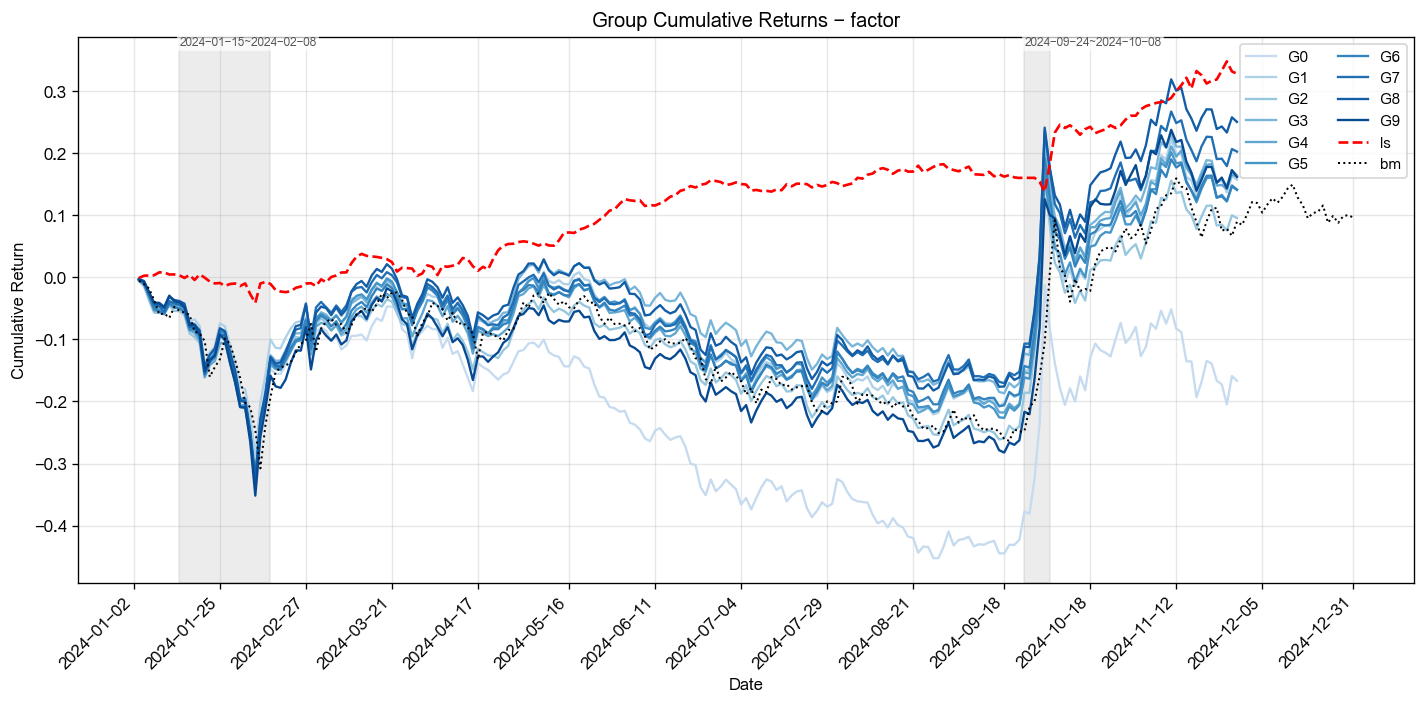
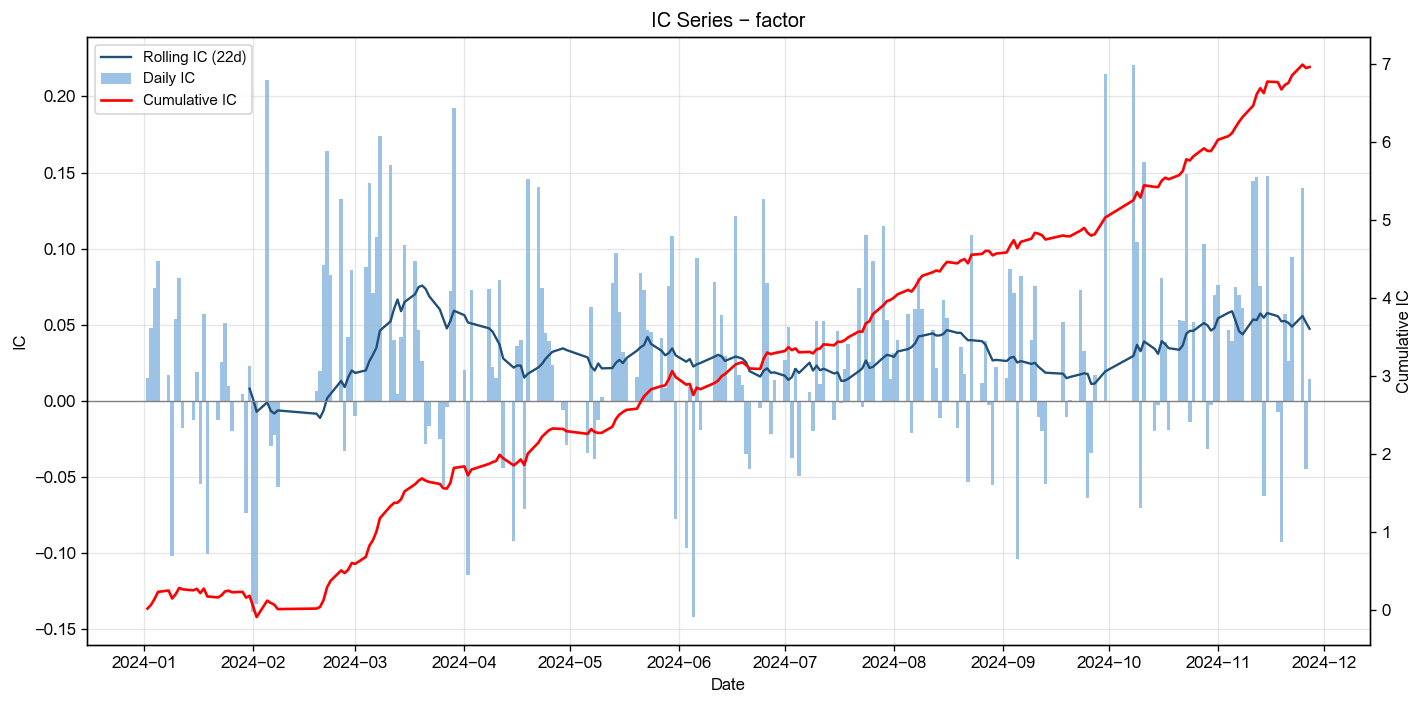
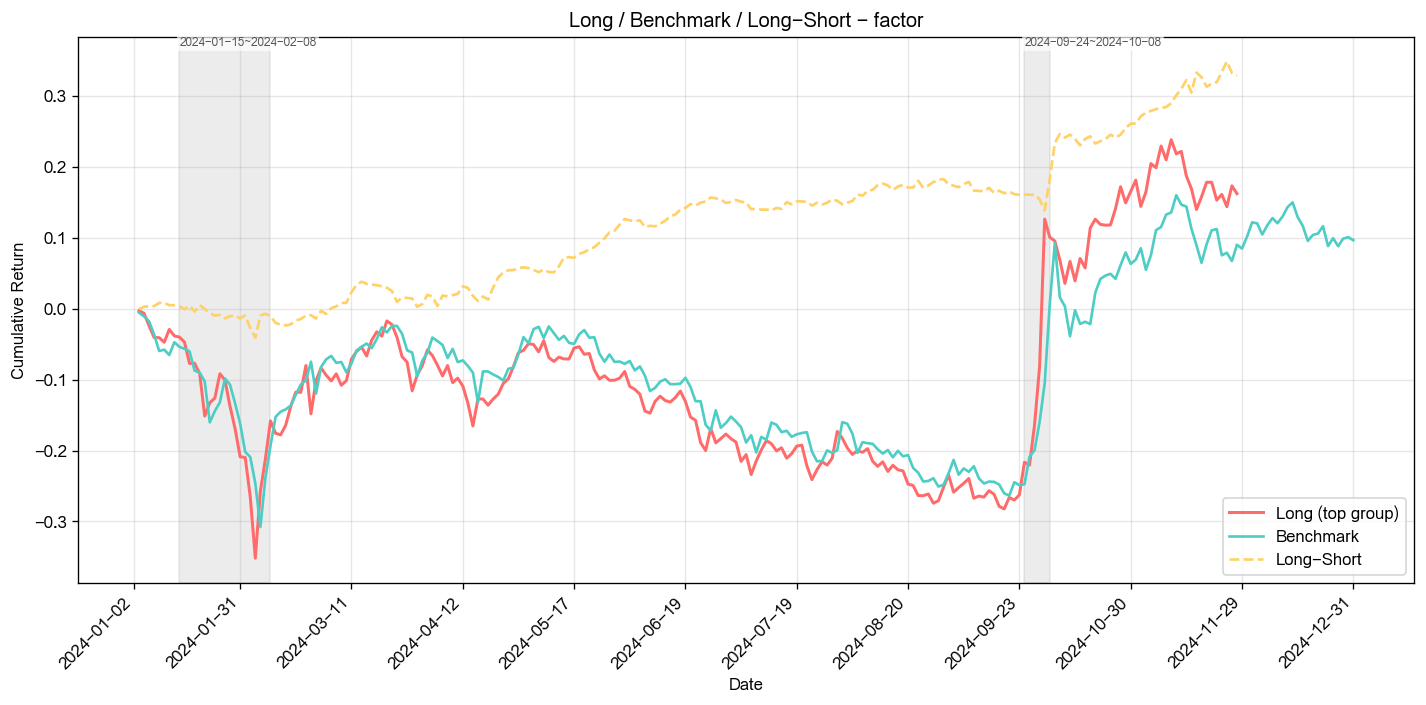
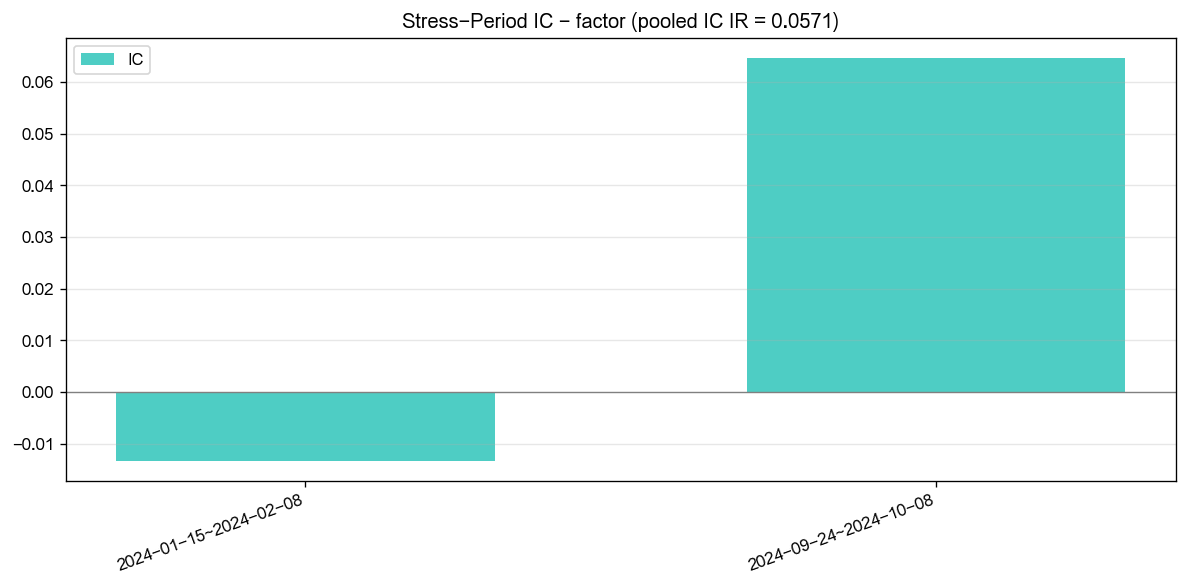
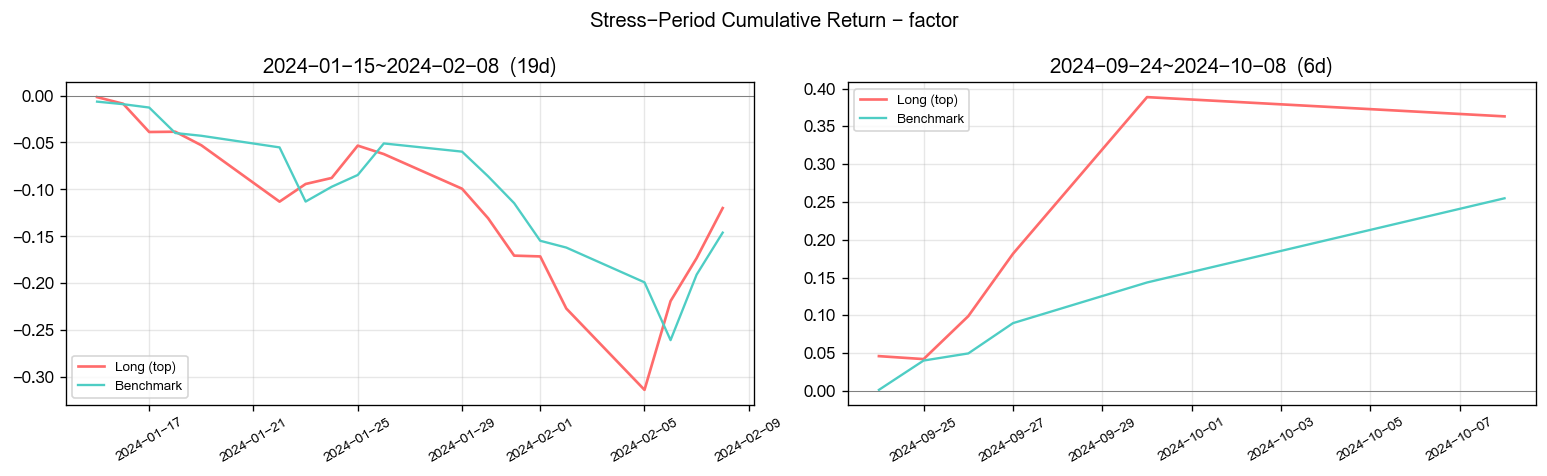

[2026-07-25 01:12:15] [info     ] ========== 因子池回归 ==========
[2026-07-25 01:12:17] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-07-25 01:12:17] [info     ] 获取收益率数据, 耗时: 1.7153 秒
[2026-07-25 01:12:18] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.1971 秒
[2026-07-25 01:12:18] [info     ] 统计 回归结果, 耗时: 0.0061 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,2.0288,0.0440,0.0217,1.0000
2,factor,2.0193,0.0331,0.0164,1.0000
3,amount,1.7573,0.0149,0.0085,0.9000
4,pb,1.6226,0.0105,0.0065,1.0000
5,net_profit_rate_ttm,1.4825,0.0040,0.0027,0.8000
6,gross_profit_rate_ttm,1.4763,0.0063,0.0043,1.0000
7,cci_14,1.3860,0.0342,0.0246,1.0000
8,netflow_amount_main,1.3757,0.0227,0.0165,0.9000
9,volatility_5,1.3683,0.0162,0.0119,1.0000
10,volume,1.3546,0.0140,0.0103,1.0000

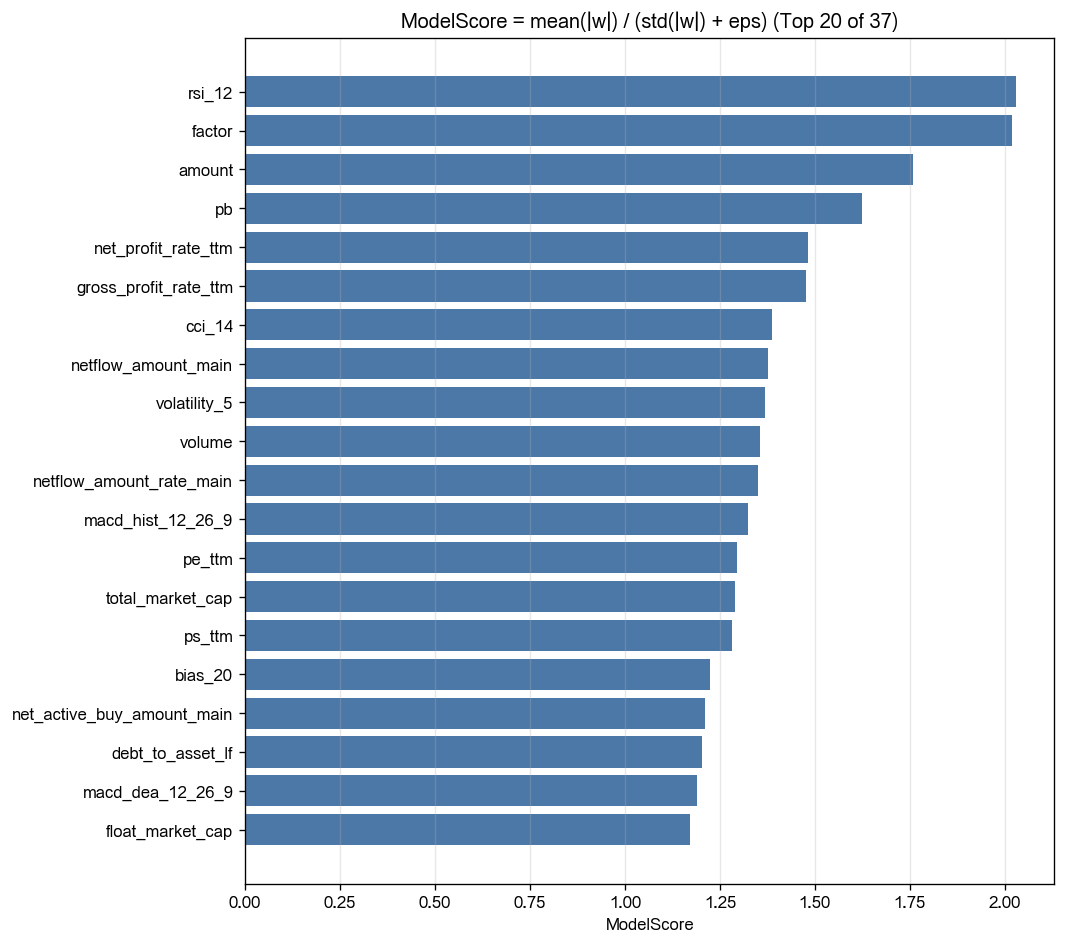
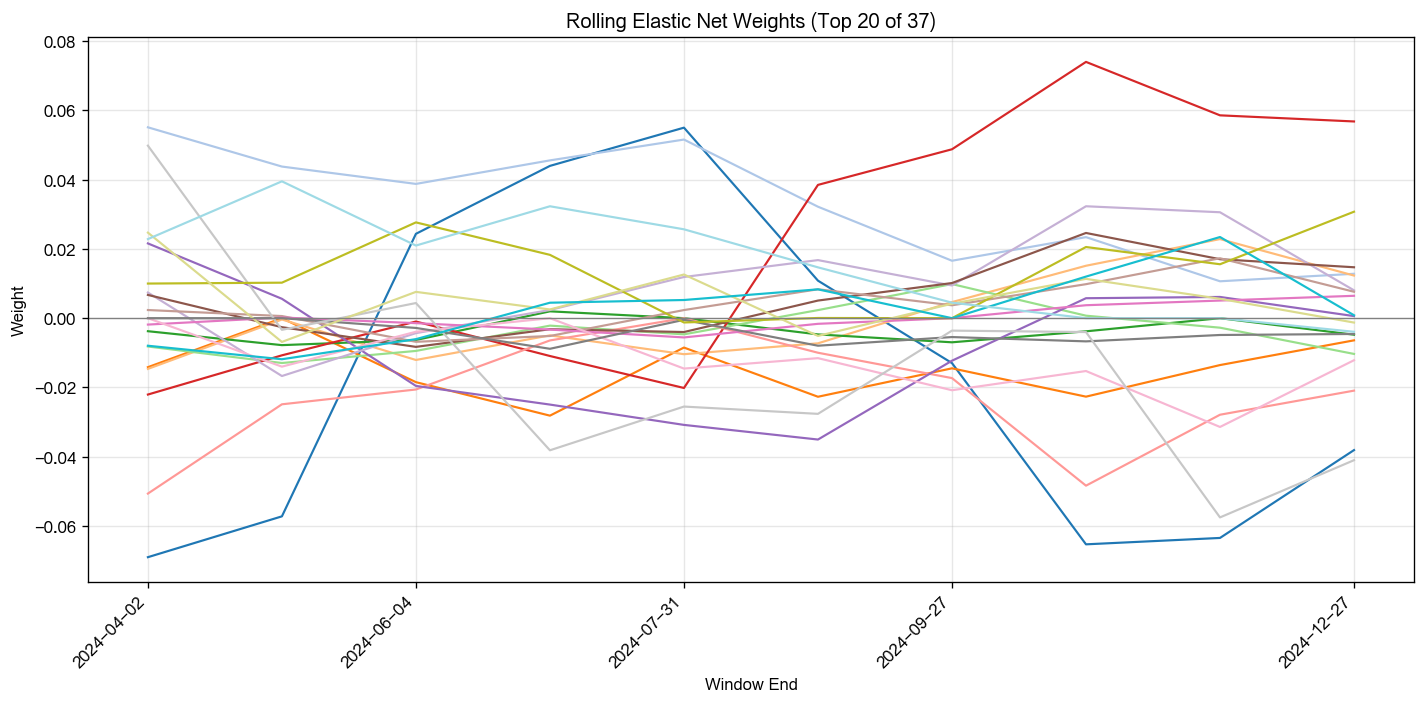
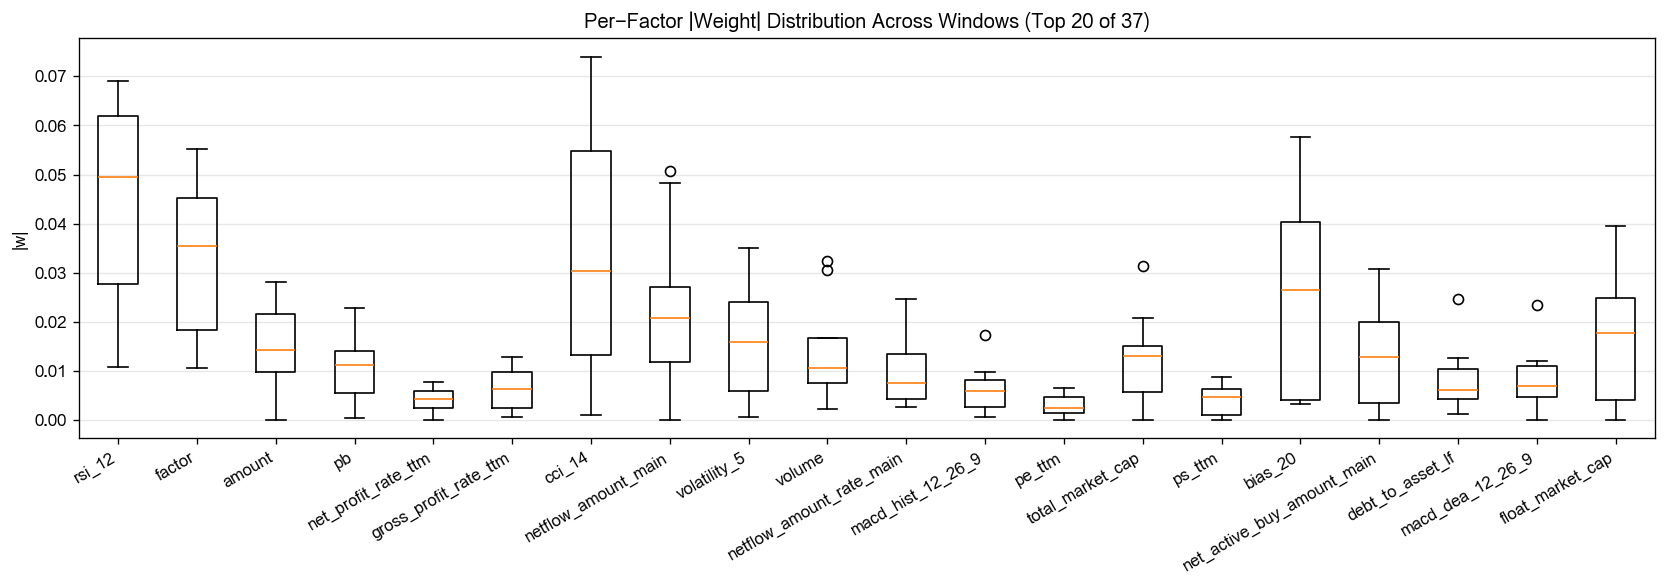
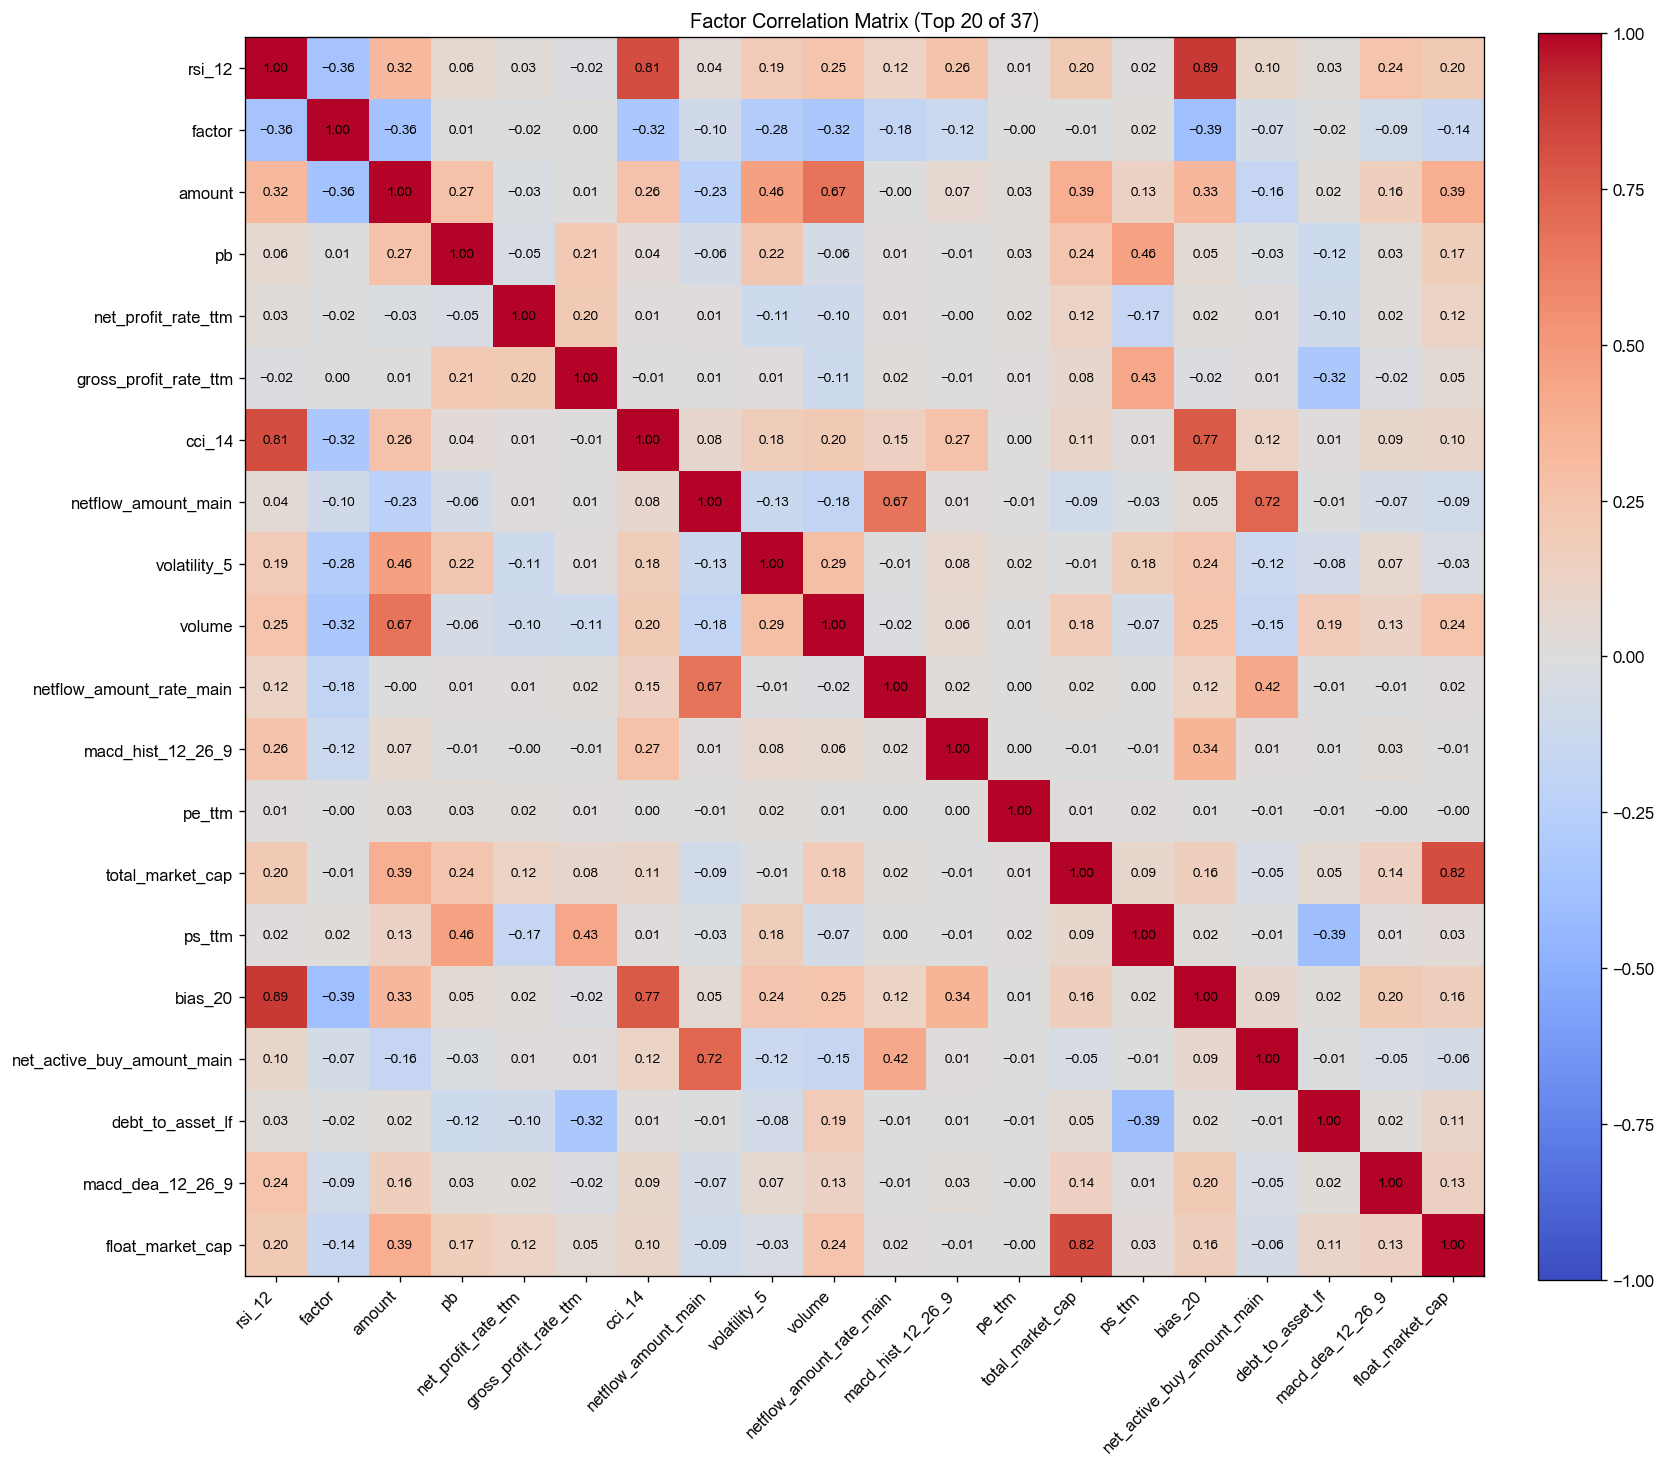

[2026-07-25 01:12:21] [warning  ] 返回的Outputs实例(size=32635097) 大于 64K, 将不会被缓存
[2026-07-25 01:12:21] [info     ] bigalpha_eval.v4 运行完成 [112.279s].


In [2]:
"""未来函数（look-ahead bias）自检工具，供参赛者自行排查因子是否偷看了未来数据。

用法
----
分别用你的 main() 跑两次，只改 end_date，其余参数（start_date、datasets）保持不变：

    df_full = main(datasets, start_date, end_date)      # 全窗
    df_cut  = main(datasets, start_date, cutoff_date)   # 截断窗，cutoff_date < end_date

    from lookahead_selfcheck import check_lookahead
    check_lookahead(df_full, df_cut, cutoff_date)

原理：因子在算某一天的值时，如果没有偷看未来数据，那么无论后面的日期是否被砍掉，
这一天算出来的值都应该完全一样。所以把 end_date 砍到 cutoff 后再跑一次，
两次结果在 date <= cutoff 的部分理应逐格一致；如果不一致，说明算 cutoff 之前某天的
因子值时用到了 cutoff 之后才有的数据，即未来函数。
"""
from __future__ import annotations

import numpy as np
import pandas as pd

_KEY_COLS = ("date", "instrument")


def check_lookahead(
    df_full: pd.DataFrame,
    df_cut: pd.DataFrame,
    cutoff: str,
    factor_col: str | None = None,
    rtol: float = 1e-5,
    atol: float = 1e-8,
) -> bool:
    """比对全窗口与截断窗口的因子输出，检查是否存在未来函数。

    Args:
        df_full: 全窗口跑 main() 得到的因子数据（含 date/instrument + 因子列）。
        df_cut:  截断窗口跑 main() 得到的因子数据，end_date 换成 cutoff，其余参数不变。
        cutoff:  截断日期 'YYYY-MM-DD'，只比对 date <= cutoff 的部分。
        factor_col: 因子列名，默认自动取 date/instrument 之外的唯一列。
        rtol/atol: 浮点比对容差，语义同 numpy.isclose。

    Returns:
        bool: True 表示未发现未来函数，False 表示发现差异（差异详情已打印）。
    """
    if factor_col is None:
        factor_col = _pick_factor_col(df_full)

    cutoff_ts = pd.Timestamp(cutoff).normalize()
    full = _prep(df_full, factor_col, cutoff_ts)
    cut = _prep(df_cut, factor_col, cutoff_ts)

    merged = pd.merge(full, cut, how="outer", on=list(_KEY_COLS), suffixes=("_full", "_cut"))
    if merged.empty:
        print(f"[未来函数自检] cutoff={cutoff_ts.date()} 前两侧都没有数据，无法判定。")
        return True

    a = merged["factor_full"].to_numpy(dtype=float)
    b = merged["factor_cut"].to_numpy(dtype=float)
    a_nan, b_nan = np.isnan(a), np.isnan(b)
    both_finite = ~a_nan & ~b_nan

    close = np.zeros(len(merged), dtype=bool)
    close[both_finite] = np.isclose(a[both_finite], b[both_finite], rtol=rtol, atol=atol)
    diff_mask = ~close & ~(a_nan & b_nan)

    diff_cells = int(diff_mask.sum())
    if diff_cells == 0:
        print(f"[未来函数自检] 通过：cutoff={cutoff_ts.date()} 前共 {len(merged)} 个格子全部一致，未发现未来函数。")
        return True

    diff_df = merged.loc[diff_mask, ["date", "instrument", "factor_full", "factor_cut"]].copy()
    diff_df["abs_dev"] = (diff_df["factor_full"] - diff_df["factor_cut"]).abs()
    first_diff_date = diff_df["date"].min().date()
    diff_ratio = diff_cells / len(merged)

    print(
        f"[未来函数自检] 发现差异：cutoff={cutoff_ts.date()} 前 {diff_cells}/{len(merged)} "
        f"({diff_ratio:.2%}) 个格子不一致，最早差异出现在 {first_diff_date}，"
        f"说明算 {first_diff_date} 这天的因子值时用到了 cutoff 之后才有的数据。"
    )
    print(diff_df.sort_values(["date", "abs_dev"], ascending=[False, False]).head(20).to_string(index=False))
    return False


def _pick_factor_col(df: pd.DataFrame) -> str:
    cols = [c for c in df.columns if c not in _KEY_COLS]
    if not cols:
        raise ValueError("未找到因子列（date/instrument 之外）")
    return cols[0]


def _prep(df: pd.DataFrame, factor_col: str, cutoff_ts: pd.Timestamp) -> pd.DataFrame:
    out = df[[*_KEY_COLS, factor_col]].copy()
    out["date"] = pd.to_datetime(out["date"]).dt.normalize()
    out["instrument"] = out["instrument"].astype(str)
    out = out.rename(columns={factor_col: "factor"})
    out["factor"] = pd.to_numeric(out["factor"], errors="coerce")
    return out[out["date"] <= cutoff_ts]


# 可调阈值（模块级，便于测试覆盖；平台评测直接使用默认值）
MIN_TRAIN_ROWS = 20000  # 月度滚动训练样本不足则该月输出 0


def main(datasources, start_date, end_date):
    """分钟级微观结构特征 + LightGBM 滚动集成因子

    评测时平台自动替换 datasources / start_date / end_date 三个入参。
    start_date~end_date 为测试区间；训练严格使用每个预测月之前的数据
    （月度 walk-forward + embargo），无任何前视。

    参数:
        datasources (dict): {"bar1m": 分钟K线表（含盘口快照）}
        start_date (str): 测试集开始时间（平台注入）
        end_date (str):   测试集结束时间（平台注入）

    返回:
        pd.DataFrame: [date, instrument, factor]，无 inf
    """
    import time
    import numpy as np
    import pandas as pd
    import dai
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
    import structlog

    logger = structlog.get_logger()

    # ===== 参数 =====
    TRAIN_MONTHS = 5        # 滚动训练窗长度（月）
    BUFFER_DAYS = 30         # 训练窗之前的特征预热缓冲（自然日）
    EMBARGO_DAYS = 6         # 训练窗与预测月之间的隔离（> 标签最长 horizon）
    SEEDS = [42, 2024, 7]    # 多种子集成
    VALID_DAYS = 40          # 训练窗尾部验证集（早停）
    min_train_rows = MIN_TRAIN_ROWS  # 读取模块级阈值

    # SQL 产出的日内微观结构特征（直接进入模型）
    SQL_FEATS = [
        'ret_std', 'ret_skew', 'ret_kurt', 'ret_max', 'ret_min',
        'down_vol_ratio', 'corr_rv', 'corr_rp',
        'vol_cv', 'vol_hhi', 'tail_vol_share', 'head_vol_share',
        'tail_ret', 'smart_q', 'obi_mean', 'obi_std', 'spread_mean',
        'amt_per_min',
    ]
    # pandas 衍生日频特征
    DAILY_FEATS = [
        'vwap_dev', 'ret_1', 'ret_5', 'ret_10', 'ret_20',
        'overnight', 'intraday', 'ex_ret_1', 'ex_ret_5',
        'vol_5', 'vol_20', 'vol_ratio', 'rel_vol5', 'amihud',
        'ema10_dev', 'ema20_dev', 'dist_high20',
    ]
    # 核心微观特征的 5 日平滑
    SMOOTH_SRC = ['corr_rv', 'ret_skew', 'down_vol_ratio', 'tail_vol_share',
                  'smart_q', 'obi_mean', 'spread_mean', 'vwap_dev', 'tail_ret']
    SMOOTH_FEATS = [c + '_5' for c in SMOOTH_SRC]

    FEATURE_COLS = SQL_FEATS + DAILY_FEATS + SMOOTH_FEATS

    # ✅ n_jobs=1 消除 LightGBM 多线程非确定性
    LGBM_PARAMS = dict(
        n_estimators=600, max_depth=6, num_leaves=31, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_samples=100,
        reg_alpha=0.1, reg_lambda=1.0, n_jobs=1, verbose=-1,
        # 确定性训练：消除多线程/列顺序引入的末位抖动
        deterministic=True, force_col_wise=True,
    )

    # ===== Stage 1: 一条 SQL 从 bar1m 聚合日内微观结构特征 =====

    def _query_micro_daily(bar1m, qstart, qend):
        """按 (instrument, 交易日) 聚合分钟 K 线 + 盘口快照。"""
        t0 = time.time()
        # ✅ 所有 ORDER BY 增加 tie-breaker，消除物理顺序依赖
        sql = f"""
        WITH cte_base AS (
            SELECT
                date, instrument,
                strftime(date, '%Y-%m-%d') AS trading_day,
                strftime(date, '%H:%M')    AS hhmm,
                open, high, low, close,
                CAST(volume AS DOUBLE) AS volume,
                CAST(amount AS DOUBLE) AS amount,
                ((COALESCE(bid_volume1,0) + COALESCE(bid_volume2,0)*0.7408
                + COALESCE(bid_volume3,0)*0.5488 + COALESCE(bid_volume4,0)*0.4066
                + COALESCE(bid_volume5,0)*0.3012)
               - (COALESCE(ask_volume1,0) + COALESCE(ask_volume2,0)*0.7408
                + COALESCE(ask_volume3,0)*0.5488 + COALESCE(ask_volume4,0)*0.4066
                + COALESCE(ask_volume5,0)*0.3012))
                / NULLIF(COALESCE(bid_volume1,0)+COALESCE(bid_volume2,0)+COALESCE(bid_volume3,0)
                       + COALESCE(bid_volume4,0)+COALESCE(bid_volume5,0)
                       + COALESCE(ask_volume1,0)+COALESCE(ask_volume2,0)+COALESCE(ask_volume3,0)
                       + COALESCE(ask_volume4,0)+COALESCE(ask_volume5,0), 0) AS obi_w,
                (ask_price1 - bid_price1) / NULLIF((ask_price1 + bid_price1)/2, 0) AS rel_spread
            FROM {bar1m}
            WHERE close > 0
        ),
        cte_ret AS (
            SELECT *,
                close / NULLIF(lag(close) OVER (
                    PARTITION BY instrument, trading_day 
                    ORDER BY date, volume DESC, amount DESC), 0) - 1 AS ret1m
            FROM cte_base
        ),
        cte_s AS (
            SELECT *,
                abs(ret1m) / sqrt(volume + 1) AS smart_s
            FROM cte_ret
        ),
        cte_rank AS (
            SELECT *,
                row_number() OVER (PARTITION BY instrument, trading_day
                                   ORDER BY smart_s DESC NULLS LAST, date) AS rn_s,
                count(*) OVER (PARTITION BY instrument, trading_day) AS n_min
            FROM cte_s
        )
        SELECT
            CAST(trading_day AS DATETIME) AS date,
            instrument,
            first(open ORDER BY date, volume DESC, amount DESC)  AS open,
            max(high)                  AS high,
            min(low)                   AS low,
            last(close ORDER BY date, volume DESC, amount DESC)  AS close,
            sum(volume)                AS volume,
            sum(amount)                AS amount,
            sum(amount) / NULLIF(sum(volume), 0) AS vwap,
            avg(amount)                AS amt_per_min,
            stddev(ret1m)              AS ret_std,
            skewness(ret1m)            AS ret_skew,
            kurtosis(ret1m)            AS ret_kurt,
            max(ret1m)                 AS ret_max,
            min(ret1m)                 AS ret_min,
            sum(CASE WHEN ret1m < 0 THEN ret1m*ret1m ELSE 0 END)
                / NULLIF(sum(ret1m*ret1m), 0)    AS down_vol_ratio,
            corr(ret1m, volume)        AS corr_rv,
            corr(ret1m, close)         AS corr_rp,
            stddev(volume) / NULLIF(avg(volume), 0) AS vol_cv,
            sum(volume*volume) / NULLIF(sum(volume)*sum(volume), 0) AS vol_hhi,
            sum(CASE WHEN hhmm >= '14:30' THEN volume ELSE 0 END)
                / NULLIF(sum(volume), 0)          AS tail_vol_share,
            sum(CASE WHEN hhmm <= '10:00' THEN volume ELSE 0 END)
                / NULLIF(sum(volume), 0)          AS head_vol_share,
            last(close ORDER BY date, volume DESC, amount DESC)
                / NULLIF(last(close ORDER BY date, volume DESC, amount DESC) 
                         FILTER (WHERE hhmm <= '14:30'), 0) - 1 AS tail_ret,
            (sum(CASE WHEN rn_s <= n_min*0.2 THEN amount ELSE 0 END)
                / NULLIF(sum(CASE WHEN rn_s <= n_min*0.2 THEN volume ELSE 0 END), 0))
                / NULLIF(sum(amount) / NULLIF(sum(volume), 0), 0) AS smart_q,
            avg(obi_w)                 AS obi_mean,
            stddev(obi_w)              AS obi_std,
            avg(rel_spread)            AS spread_mean
        FROM cte_rank
        GROUP BY trading_day, instrument
        ORDER BY instrument, trading_day
        """
        df = dai.query(
            sql,
            filters={'date': [qstart.strftime('%Y-%m-%d %H:%M:%S'), qend]},
            compression=False,
        ).df()
        df['date'] = pd.to_datetime(df['date'])
        df['instrument'] = df['instrument'].astype(str)
        numeric_cols = df.select_dtypes(include=[np.number]).columns
        df[numeric_cols] = df[numeric_cols].round(2)
        logger.info("Stage1 微观结构聚合完成", rows=len(df), elapsed=round(time.time() - t0, 1))
        return df

    # ===== Stage 2: pandas 衍生日频特征 =====

    def _build_features(df):
        t0 = time.time()
        df = df.sort_values(['instrument', 'date', 'volume', 'amount']).reset_index(drop=True)
        df = df.drop_duplicates(['instrument', 'date'], keep='last').reset_index(drop=True)
        
        gi = df.groupby('instrument', sort=True)

        prev_close = gi['close'].shift(1)
        df['ret_1'] = df['close'] / prev_close - 1
        df['overnight'] = df['open'] / prev_close - 1
        df['intraday'] = df['close'] / df['open'] - 1
        df['vwap_dev'] = df['close'] / df['vwap'] - 1
        for w in (5, 10, 20):
            df[f'ret_{w}'] = df['close'] / gi['close'].shift(w) - 1

        df['ex_ret_1'] = df['ret_1'] - df.groupby('date', sort=True)['ret_1'].transform('mean')
        df['ex_ret_5'] = df['ret_5'] - df.groupby('date', sort=True)['ret_5'].transform('mean')

        def _roll(col, window, func, minp=None):
            r = df.groupby('instrument', sort=True)[col].rolling(
                window, min_periods=minp or max(2, window // 2))
            return getattr(r, func)().reset_index(level=0, drop=True)

        df['vol_5'] = _roll('ret_1', 5, 'std')
        df['vol_20'] = _roll('ret_1', 20, 'std')
        df['vol_ratio'] = df['vol_5'] / (df['vol_20'] + 1e-12)
        vol_ma20 = _roll('volume', 20, 'mean')
        df['rel_vol5'] = df['volume'] / (vol_ma20 + 1e-12)
        df['amihud'] = df['ret_1'].abs() / (df['amount'] + 1.0)

        ema10 = df.groupby('instrument', sort=True)['close'].ewm(span=10, adjust=False).mean()
        ema20 = df.groupby('instrument', sort=True)['close'].ewm(span=20, adjust=False).mean()
        df['ema10_dev'] = df['close'] / ema10.reset_index(level=0, drop=True) - 1
        df['ema20_dev'] = df['close'] / ema20.reset_index(level=0, drop=True) - 1
        df['dist_high20'] = df['close'] / (_roll('high', 20, 'max') + 1e-12) - 1

        for c in SMOOTH_SRC:
            df[c + '_5'] = _roll(c, 5, 'mean')

        df[FEATURE_COLS] = df[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
        df[FEATURE_COLS] = df[FEATURE_COLS].round(2)
        logger.info("Stage2 特征构建完成", rows=len(df), elapsed=round(time.time() - t0, 1))
        return df

    # ===== Stage 3: 标签（1 日 + 5 日前瞻收益截面分位混合） =====
    # 标签不再全局计算，移到 _walk_forward 内部仅对训练集切片计算。

    def _build_label(df):
        gi = df.groupby('instrument', sort=True)
        fwd_s = gi['close'].shift(-1) / df['close'] - 1
        fwd_l = gi['close'].shift(-5) / df['close'] - 1
        df['label'] = (0.5 * fwd_s.groupby(df['date'], sort=True).rank(pct=True)
                       + 0.5 * fwd_l.groupby(df['date'], sort=True).rank(pct=True))
        return df

    # ===== Stage 4: 月度 walk-forward 训练 + 多种子集成 =====

    def _walk_forward(df, start_ts, end_ts):
        test_mask = (df['date'] >= start_ts) & (df['date'] <= end_ts)
        test_dates = pd.Series(df.loc[test_mask, 'date'].unique())
        months = test_dates.dt.to_period('M').unique()
        logger.info("walk-forward 月份数", n=len(months))

        preds = []
        for m in months:
            m_start, m_end = m.start_time, m.end_time
            p_mask = test_mask & (df['date'] >= m_start) & (df['date'] <= m_end)
            p_df = df.loc[p_mask]
            if len(p_df) == 0:
                continue

            t_end = m_start - pd.Timedelta(days=EMBARGO_DAYS)
            t_start = m_start - pd.DateOffset(months=TRAIN_MONTHS)
            tr = df[(df['date'] >= t_start) & (df['date'] <= t_end)].copy()

            # ✅ 仅在训练集内部计算 label
            tr = _build_label(tr)
            tr = tr.dropna(subset=['label'])

            p_df = p_df.copy()
            if len(tr) < min_train_rows:
                logger.info("训练样本不足，输出 0", month=str(m), rows=len(tr))
                p_df['factor'] = 0.0
                preds.append(p_df[['date', 'instrument', 'factor']])
                continue

            tr = tr.sort_values(['date', 'instrument']).reset_index(drop=True)
            p_df = p_df.sort_values(['date', 'instrument']).reset_index(drop=True)

            tr_dates = np.sort(tr['date'].unique())
            n_va = min(VALID_DAYS, max(5, len(tr_dates) // 10))
            va_set = set(tr_dates[-n_va:])
            va_mask = tr['date'].isin(va_set)
            X_tr, y_tr = tr.loc[~va_mask, FEATURE_COLS], tr.loc[~va_mask, 'label']
            X_va, y_va = tr.loc[va_mask, FEATURE_COLS], tr.loc[va_mask, 'label']
            X_p = p_df[FEATURE_COLS]

            t0 = time.time()
            ens = np.zeros(len(p_df))
            for seed in SEEDS:
                model = LGBMRegressor(random_state=seed, **LGBM_PARAMS)
                model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
                          callbacks=[lgb.early_stopping(60, verbose=False)])
                ens += model.predict(X_p)
            p_df['factor'] = ens / len(SEEDS)
            logger.info("月份训练完成", month=str(m), train=len(tr),
                        best_iter=model.best_iteration_, elapsed=round(time.time() - t0, 1))
            preds.append(p_df[['date', 'instrument', 'factor']])

        if not preds:
            return pd.DataFrame(columns=['date', 'instrument', 'factor'])
        return pd.concat(preds, ignore_index=True)

    # ===== 主逻辑 =====

    start_ts = pd.to_datetime(start_date)
    end_ts = pd.to_datetime(end_date)
    qstart = start_ts - pd.DateOffset(months=TRAIN_MONTHS) - pd.Timedelta(days=BUFFER_DAYS)

    # ✅ Stage 1: 分块查询，避免一次性拉取过多数据导致磁盘空间不足
    # 按自然月分块；SQL 中的 lag/聚合都是日内的（PARTITION BY trading_day），
    # 跨月分块不会影响结果。
    daily_chunks = []
    chunk_start = qstart.replace(day=1, hour=0, minute=0, second=0)
    while chunk_start <= end_ts:
        chunk_end = min((chunk_start + pd.DateOffset(months=1)) - pd.Timedelta(seconds=1), end_ts)
        chunk_df = _query_micro_daily(datasources['bar1m'], chunk_start, chunk_end)
        daily_chunks.append(chunk_df)
        chunk_start = chunk_start + pd.DateOffset(months=1)
    
    daily = pd.concat(daily_chunks, ignore_index=True)
    daily = daily.drop_duplicates(['date', 'instrument'], keep='last')
    daily = daily.sort_values(['instrument', 'date']).reset_index(drop=True)
    logger.info("Stage1 分块合并完成", total_rows=len(daily), chunks=len(daily_chunks))

    # Stage 2
    daily = _build_features(daily)
    # Stage 4
    result = _walk_forward(daily, start_ts, end_ts)

    # 截面 z-score + 异常值处理
    result['factor'] = result.groupby('date', sort=True)['factor'].transform(
        lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-12))
    result['factor'] = result['factor'].clip(-5, 5)
    result['factor'] = result['factor'].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    result['factor'] = result['factor'].round(2)

    # Stage 5: 对齐中证 1000 成分股
    try:
        stk_pool = dai.query(
            "SELECT date, instrument FROM bigalpha_2026_instruments",
            filters={'date': [start_date, end_date]},
        ).df()
        stk_pool['instrument'] = stk_pool['instrument'].astype(str)
        stk_pool = stk_pool.sort_values(['date', 'instrument']).reset_index(drop=True)
        result = result.sort_values(['date', 'instrument']).reset_index(drop=True)
        result = pd.merge(result, stk_pool, how='inner', on=['date', 'instrument'])
    except Exception as e:
        logger.warning("股票池对齐失败，跳过过滤", error=str(e))

    result = result.drop_duplicates(['date', 'instrument'], keep='last')
    logger.info("因子构建完成", rows=len(result))
    return result[['date', 'instrument', 'factor']].reset_index(drop=True)

if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"）
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m'}
    # 本地用这段区间模拟「平台注入的测试集区间」（训练区间在 main 内自动向前滚动）
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"计算因子，测试区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )
